Exercise 3 

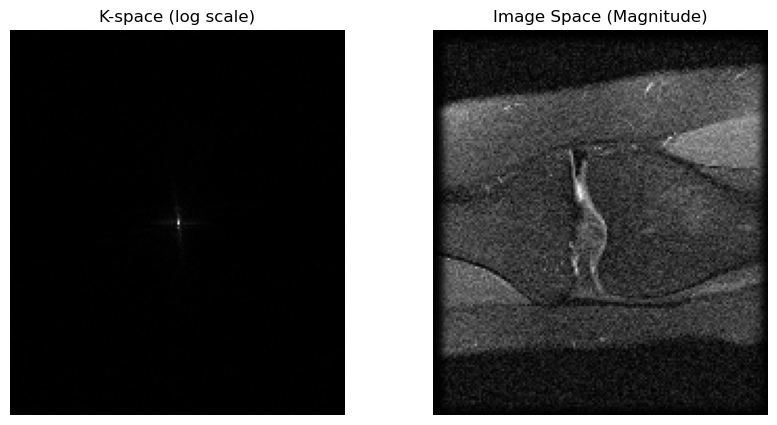

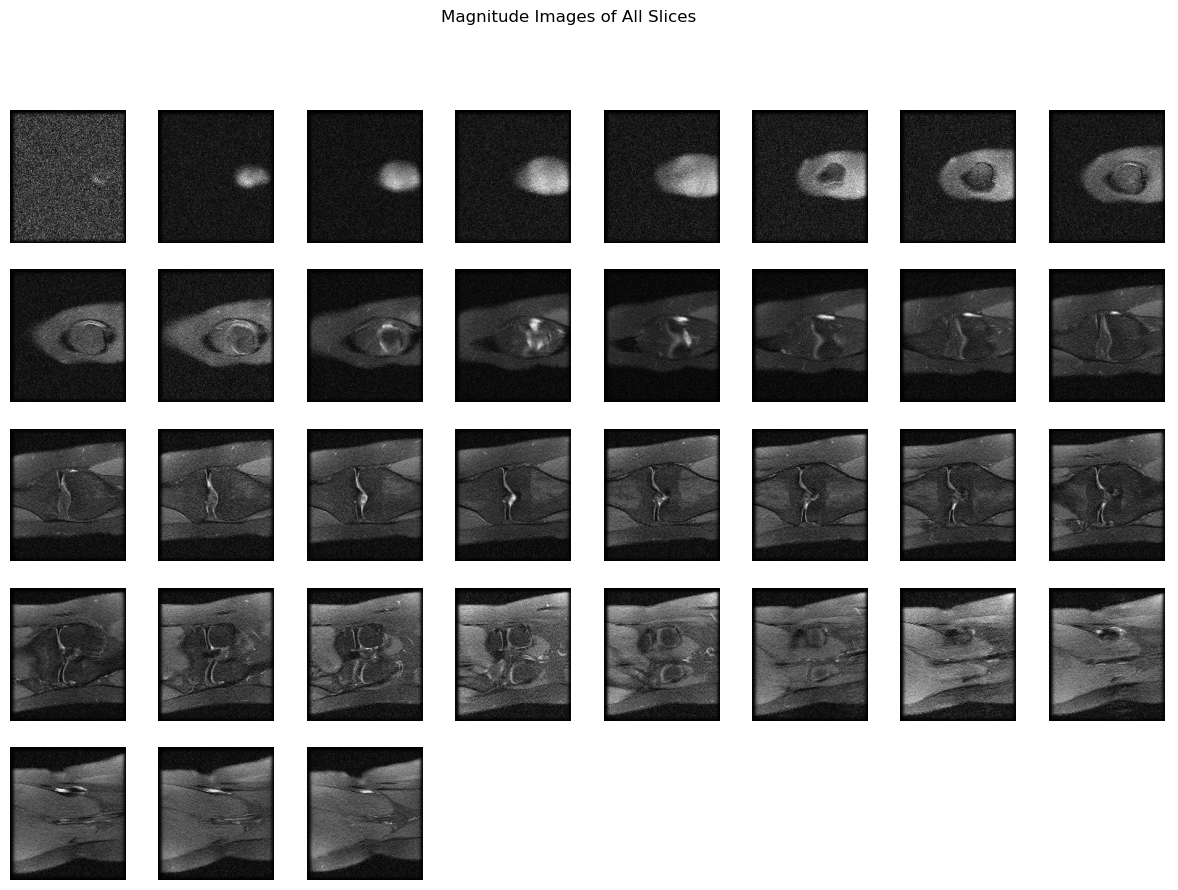

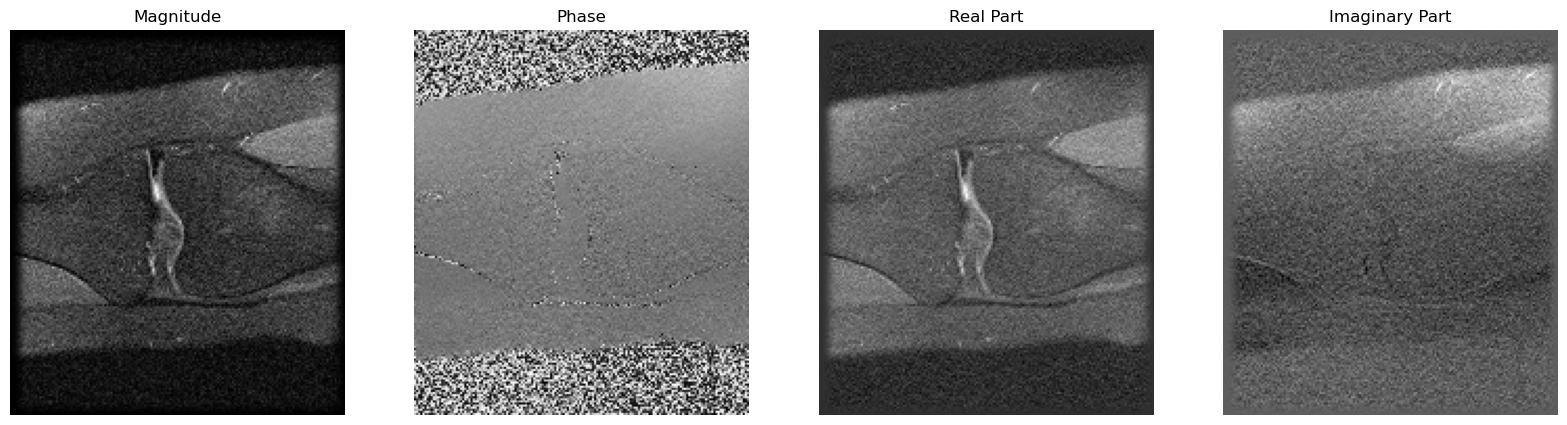

Phase range in image domain: (-3.1407044474714336, 3.1412539118333926)


In [7]:
import h5py
import numpy as np
import matplotlib.pyplot as plt

# Load the h5 file (replace 'your_file.h5' with the actual file path)
file_path = '/Users/elenaliarou/Downloads/FastMRIdata/multicoil_train/file147.h5'
with h5py.File(file_path, 'r') as hf:
    kspace = hf['kspace'][:]  # Load k-space data

# Select the center slice
center_slice_idx = kspace.shape[0] // 2
kspace_center_slice = kspace[center_slice_idx]

# Compute image space using inverse Fourier Transform
image_space = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_center_slice)))
kspace_center_slice = np.squeeze(kspace_center_slice)  # Remove singleton dimension
image_space = np.squeeze(image_space)  # Ensure it's 2D

# Plot k-space and image-space for the center slice
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(np.log1p(np.abs(kspace_center_slice)), cmap='gray')
axes[0].set_title("K-space (log scale)")
axes[0].axis("off")

axes[1].imshow(np.abs(image_space), cmap='gray')
axes[1].set_title("Image Space (Magnitude)")
axes[1].axis("off")

plt.show()

# Plot magnitude images for all slices in a tiled display
num_slices = kspace.shape[0]
cols = 8
rows = (num_slices + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(15, 10))
for i in range(rows * cols):
    ax = axes[i // cols, i % cols]
    if i < num_slices:
        image_slice = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace[i])))
        image_slice = np.squeeze(image_slice)
        ax.imshow(np.abs(image_slice), cmap='gray')
    ax.axis("off")
plt.suptitle("Magnitude Images of All Slices")
plt.show()

# Plot magnitude, phase, real, and imaginary components for the center slice
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(np.abs(image_space), cmap='gray')
axes[0].set_title("Magnitude")
axes[0].axis("off")

axes[1].imshow(np.angle(image_space), cmap='gray')
axes[1].set_title("Phase")
axes[1].axis("off")

axes[2].imshow(np.real(image_space), cmap='gray')
axes[2].set_title("Real Part")
axes[2].axis("off")

axes[3].imshow(np.imag(image_space), cmap='gray')
axes[3].set_title("Imaginary Part")
axes[3].axis("off")

plt.show()

# Compute the range of phase values
phase_values = np.angle(image_space)
phase_range = (np.min(phase_values), np.max(phase_values))
print("Phase range in image domain:", phase_range)

Masking

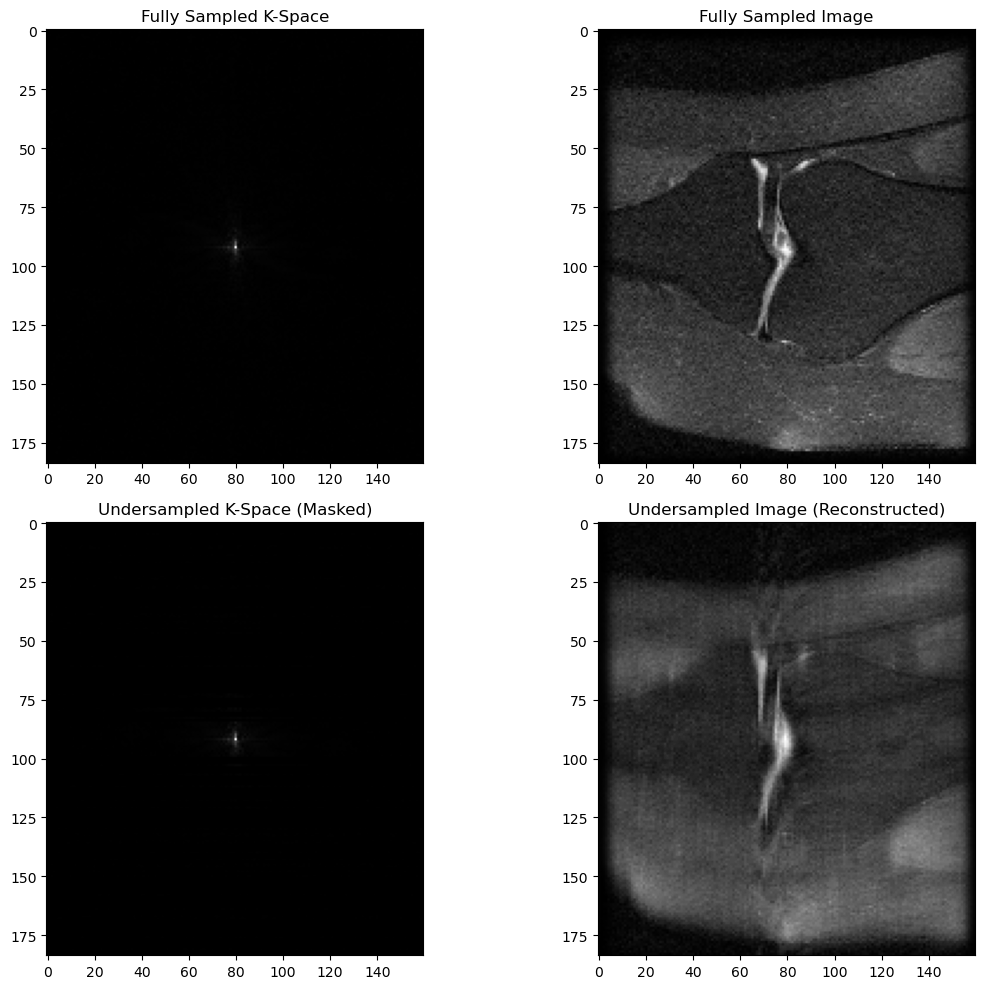

In [21]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from fastmri.data.subsample import create_mask_for_mask_type
from fastmri import fft2c, ifft2c

# Load test scan
test_file_path = "/Users/elenaliarou/Downloads/FastMRIdata/multicoil_test/file142.h5"
with h5py.File(test_file_path, "r") as hf:
    kspace_test = hf["kspace"][:]  # Load k-space data

# Select center slice
center_slice_idx = kspace_test.shape[0] // 2
kspace_center_test = kspace_test[center_slice_idx]

# Fully sampled reconstruction (for comparison)
image_test_full = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_center_test)))

# Get the shape of kspace_center_test
shape = kspace_center_test.shape

# Create a mask function
mask_function = create_mask_for_mask_type(mask_type_str="random", center_fractions=[0.08], accelerations=[4])

# Generate mask for the k-space shape and extract the mask separately
mask, acc = mask_function((1, *shape))  # Ensure the shape has the correct dimensions
mask = mask[0, 0]  # Convert from 4D to 2D

# Apply mask to k-space
kspace_test_masked = kspace_center_test * mask.numpy().astype(kspace_center_test.dtype)

# Reconstruct the undersampled image
image_test_subsampled = np.fft.ifftshift(np.fft.ifft2(np.fft.fftshift(kspace_test_masked)))

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Fully sampled
axes[0, 0].imshow(np.log1p(np.abs(np.squeeze(kspace_center_test))), cmap='gray')
axes[0, 0].set_title("Fully Sampled K-Space")
axes[0, 1].imshow(np.abs(np.squeeze(image_test_full)), cmap='gray')
axes[0, 1].set_title("Fully Sampled Image")

# Undersampled
axes[1, 0].imshow(np.log1p(np.abs(np.squeeze(kspace_test_masked))), cmap='gray')
axes[1, 0].set_title("Undersampled K-Space (Masked)")
axes[1, 1].imshow(np.abs(np.squeeze(image_test_subsampled)), cmap='gray')
axes[1, 1].set_title("Undersampled Image (Reconstructed)")

plt.tight_layout()
plt.show()
